## Document Ingestion

Document ingestion is the process of loading raw documents, extracting their
content, preserving useful metadata, and converting them into a standardized
representation that can be passed to the chunking stage.

In this experiment, two document types are used:

1. Recursive-friendly document
   - `asthma_patient_information.pdf`

2. Structure-sensitive document
   - `asthma_reference.md`

The ingestion pipeline will:

- identify the input files
- extract text from each document
- preserve source and file-type metadata
- preserve PDF page information
- normalize the extracted content
- create a consistent representation for downstream chunking

Pipeline:

Raw Documents → File Detection → Text Extraction → Metadata →
Normalization → Standardized Documents → Chunking

                 ┌───────────────────────┐
                 │     Raw Documents     │
                 └───────────┬───────────┘
                             │
                 ┌───────────▼───────────┐
                 │   Detect file type    │
                 └───────────┬───────────┘
                             │
                ┌────────────┴────────────┐
                │                         │
          PDF Loader                 MD Loader
                │                         │
          Extract text              Read text
          + page number              + metadata
                │                         │
                └────────────┬────────────┘
                             ↓
                    Normalize / Clean
                             ↓
                  Standard Document Format
                             ↓
                        Chunking

#### Imports

In [1]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import pymupdf  # PyMuPDF
from pathlib import Path
from collections import Counter
from langchain_core.documents import Document
import matplotlib.pyplot as plt

from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

/home/as/Downloads/Repos/DailyTask/Sessions/session-1-recursive-chunking/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = Path.cwd()

RECURSIVE_FRIENDLY_DIR = BASE_DIR / "data" / "recursive_friendly"
STRUCTURE_SENSITIVE_DIR = BASE_DIR / "data" / "structure_sensitive"

PDF_PATH = RECURSIVE_FRIENDLY_DIR / "asthma_patient_information.pdf"
MD_PATH = STRUCTURE_SENSITIVE_DIR / "asthma_reference.md"

print("PDF:", PDF_PATH)
print("Markdown:", MD_PATH)

print("\nPDF exists:", PDF_PATH.exists())
print("Markdown exists:", MD_PATH.exists())

PDF: /home/as/Downloads/Repos/DailyTask/Sessions/session-1-recursive-chunking/data/recursive_friendly/asthma_patient_information.pdf
Markdown: /home/as/Downloads/Repos/DailyTask/Sessions/session-1-recursive-chunking/data/structure_sensitive/asthma_reference.md

PDF exists: True
Markdown exists: True


### PDF Ingestion

The PDF is treated as a page-aware document.

For each page we extract:

- page text
- source filename
- file type
- page number

Preserving page information allows retrieved chunks to be traced back
to their original location in the source document.

In [3]:
def load_pdf(path):
    """
    Load a PDF page by page.

    Each page becomes a LangChain Document.
    """

    documents = []

    pdf = pymupdf.open(path)

    for page_number, page in enumerate(pdf, start=1):
        text = page.get_text("text")

        documents.append(
            Document(
                page_content=text,
                metadata={
                    "source": path.name,
                    "file_type": "pdf",
                    "page": page_number
                }
            )
        )

    pdf.close()

    return documents

pdf_documents = load_pdf(PDF_PATH)
# print(pdf_documents)
print("Number of PDF pages:", len(pdf_documents))

Number of PDF pages: 4


In [4]:
# Inspect the first page:
print(pdf_documents[0].metadata)
print()
print(pdf_documents[0].page_content[:1500])

{'source': 'asthma_patient_information.pdf', 'file_type': 'pdf', 'page': 1}

 
 
1 
Leaflet title: Asthma: What you need to know 
Version date: June 2026 
 
 
 
Asthma: What you need to know 
 
Asthma Service, Chest Clinic 
 
What is asthma?  
Asthma is a common condition that affects the airways in and out of your lungs. 
These airways can become sensitive and inflamed, making it harder to breath and 
causing symptoms such as coughing, wheezing, shortness of breath, and chest 
tightness. 
Because the airways are so sensitive, certain things 
can trigger the muscles around the airways to 
tighten. This makes the airways narrower. The airway 
lining also becomes inflamed, causing the further 
narrowing of the airways and increased sputum 
production. 
Why do people get asthma? 
There is no simple answer to this question. Whilst asthma often starts in childhood, it 
can develop at any stage in life. What we do know is that some things make asthma 
more likely: 
• It can run in families –

### Markdown Ingestion

The structure-sensitive document is a Markdown file.

Unlike the PDF, Markdown already contains structural markers such as:

- headings
- subheadings
- lists
- numbered lists
- tables
- blockquotes
- metadata

At the ingestion stage, we should therefore avoid destroying this structure.

The original Markdown content will be preserved as a single document.

In [5]:
def load_markdown(path):
    """
    Load a Markdown document while preserving
    its original structure.
    """
    
    text = path.read_text(encoding="utf-8")

    return [
        Document(
            page_content=text,
            metadata={
                "source": path.name,
                "file_type": "markdown"
            }
        )
    ]

markdown_documents = load_markdown(MD_PATH)

print("Number of Markdown documents:", len(markdown_documents))

print("\nMetadata:")
print(markdown_documents[0].page_content)

print("\nPreview:")
print(markdown_documents[0].metadata)

Number of Markdown documents: 1

Metadata:
# Asthma: What You Need to Know

**Source:** Asthma Service, Chest Clinic

**Leaflet Title:** Asthma: What you need to know

**Version Date:** June 2026

---

## 1. Overview & Diagnosis

### What is Asthma?

Asthma is a common condition that affects the airways in and out of your lungs. These airways can become sensitive and inflamed, making it harder to breathe and causing symptoms such as:

- Coughing
- Wheezing
- Shortness of breath
- Chest tightness

> **Airway Mechanism:** Sensitive airways cause triggers to tighten surrounding muscles, narrowing the airway. Simultaneous airway lining inflammation leads to further narrowing and increased sputum production.

### Diagnosis

There is **no single test** to diagnose asthma. Diagnosis is made based on:

1. Your symptom history
2. Results of breathing tests

---

## 2. Causes & Triggers

### Why Do People Get Asthma?

While often starting in childhood, asthma can develop at any stage of life. Ke

### Text Normalization

Normalization should be conservative.

The goal is to remove extraction noise without destroying meaningful
document structure.

Examples of safe normalization include:

- converting Windows line endings to Unix-style line endings
- removing unnecessary trailing whitespace
- reducing excessive blank lines

For Markdown, headings, bullets, tables, and other structural markers
must be preserved.

In [6]:
def normalize_text(text):
    """
    Perform conservative text normalization.
    """
    
    # Normalize line endings
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    
    # Remove trailing whitespace from each line
    text = "\n".join(line.rstrip() for line in text.split("\n"))
    
    # Reduce excessive blank lines while preserving paragraph separation
    text = re.sub(r"\n{3,}", "\n\n", text)
    
    return text.strip()

for document in pdf_documents:
    document.page_content = normalize_text(document.page_content)

for document in markdown_documents:
    document.page_content = normalize_text(document.page_content)

### Ingestion Summary

Before moving to chunking, we verify:

- number of source files
- number of extracted document units
- document types
- character counts
- available metadata

This provides a reproducible baseline for the later chunking experiment.

In [9]:
file_types = Counter(
    document.metadata["file_type"]
    for document in documents
)

print("Document units:", len(documents))
print("File types:", dict(file_types))

print("\nCharacter counts:")

for document in documents:

    metadata = document.metadata

    location = (
        f"page {metadata['page']}"
        if "page" in metadata
        else "whole document"
    )

    print(
        f"- {metadata['source']} | "
        f"{location} | "
        f"{len(document.page_content)} characters"
    )

Document units: 5
File types: {'pdf': 4, 'markdown': 1}

Character counts:
- asthma_patient_information.pdf | page 1 | 1511 characters
- asthma_patient_information.pdf | page 2 | 2081 characters
- asthma_patient_information.pdf | page 3 | 1993 characters
- asthma_patient_information.pdf | page 4 | 471 characters
- asthma_reference.md | whole document | 5126 characters


### Ingestion Validation

Before passing documents to the chunking stage, we validate that:

1. The expected files exist.
2. Text was successfully extracted.
3. No document is unexpectedly empty.
4. Metadata is available.
5. PDF page information was preserved.
6. Markdown structural markers are still present.

In [10]:
def validate_documents(documents):
    """
    Basic validation for ingested documents.
    """
    
    assert len(documents) > 0, "No documents were ingested."
    
    for document in documents:
        text = document.page_content
        metadata = document.metadata
        
        assert text.strip(), (
            f"Empty document: {metadata}"
        )
        
        assert "source" in metadata, (
            f"Missing source metadata: {metadata}"
        )
        
        assert "file_type" in metadata, (
            f"Missing file_type metadata: {metadata}"
        )
        
        if metadata["file_type"] == "pdf":
            assert "page" in metadata, (
                f"PDF page metadata missing: {metadata}"
            )
    
    print("✓ All ingestion validation checks passed.")
validate_documents(documents)

✓ All ingestion validation checks passed.


# Recursive Chunking

This phase investigates Recursive Character Text Splitting as the primary
chunking strategy.

The two document collections are evaluated separately:

1. Recursive-friendly PDF
   - `asthma_patient_information.pdf`

2. Structure-sensitive Markdown
   - `asthma_reference.md`

The main experimental variable is `chunk_size`.

Rather than assuming that a single chunk size is optimal, multiple values
will be tested and their effects on chunk statistics and, later, retrieval
performance will be evaluated.

Initial values:

- 200
- 300
- 400
- 500
- 700 characters

The same overlap and separator configuration will initially be kept fixed
so that chunk size is the main changing variable.

In [11]:
CHUNK_OVERLAP = 50

SEPARATORS = [
    "\n\n",
    "\n",
    ". ",
    " ",
    ""
]

CHUNK_SIZES = [200, 300, 400, 500, 700]

In [12]:
def create_recursive_splitter(chunk_size, chunk_overlap=50):
    return RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=SEPARATORS
    )

### First experiment: chunk size 200

In [13]:
recursive_splitter_200 = create_recursive_splitter(CHUNK_SIZES[0]) #200

pdf_chunks_200 = recursive_splitter_200.split_documents(
    pdf_documents
)

print("PDF chunks:", len(pdf_chunks_200))


PDF chunks: 41


In [14]:
for i, chunk in enumerate(pdf_chunks_200[:5], start=1):
    print(f"\n--- PDF Chunk {i} ---")
    print("Metadata:", chunk.metadata)
    print("Characters:", len(chunk.page_content))
    print(chunk.page_content)


--- PDF Chunk 1 ---
Metadata: {'source': 'asthma_patient_information.pdf', 'file_type': 'pdf', 'page': 1}
Characters: 131
1
Leaflet title: Asthma: What you need to know
Version date: June 2026

Asthma: What you need to know

Asthma Service, Chest Clinic

--- PDF Chunk 2 ---
Metadata: {'source': 'asthma_patient_information.pdf', 'file_type': 'pdf', 'page': 1}
Characters: 175
What is asthma?
Asthma is a common condition that affects the airways in and out of your lungs.
These airways can become sensitive and inflamed, making it harder to breath and

--- PDF Chunk 3 ---
Metadata: {'source': 'asthma_patient_information.pdf', 'file_type': 'pdf', 'page': 1}
Characters: 185
causing symptoms such as coughing, wheezing, shortness of breath, and chest
tightness.
Because the airways are so sensitive, certain things
can trigger the muscles around the airways to

--- PDF Chunk 4 ---
Metadata: {'source': 'asthma_patient_information.pdf', 'file_type': 'pdf', 'page': 1}
Characters: 194
can trigger th

### Second experiment: chunk size 300

In [15]:
recursive_splitter_300 = create_recursive_splitter(CHUNK_SIZES[1]) #300

pdf_chunks_300 = recursive_splitter_300.split_documents(
    pdf_documents
)

print("PDF chunks:", len(pdf_chunks_300))

PDF chunks: 27


In [16]:
# for i, chunk in enumerate(pdf_chunks_300[:5], start=1):
#     print(f"\n--- PDF Chunk {i} ---")
#     print("Metadata:", chunk.metadata)
#     print("Characters:", len(chunk.page_content))
#     print(chunk.page_content)

### Third experiment: chunk size 400

In [17]:
recursive_splitter_400 = create_recursive_splitter(CHUNK_SIZES[2]) #400

pdf_chunks_400 = recursive_splitter_400.split_documents(
    pdf_documents
)

print("PDF chunks:", len(pdf_chunks_400))

PDF chunks: 21


In [18]:
# for i, chunk in enumerate(pdf_chunks_400[:5], start=1):
#     print(f"\n--- PDF Chunk {i} ---")
#     print("Metadata:", chunk.metadata)
#     print("Characters:", len(chunk.page_content))
#     print(chunk.page_content)

### Fourth experiment: chunk size 500

In [19]:
recursive_splitter_500 = create_recursive_splitter(CHUNK_SIZES[3]) #500

pdf_chunks_500 = recursive_splitter_500.split_documents(
    pdf_documents
)

print("PDF chunks:", len(pdf_chunks_500))

PDF chunks: 16


In [20]:
# for i, chunk in enumerate(pdf_chunks_500[:5], start=1):
#     print(f"\n--- PDF Chunk {i} ---")
#     print("Metadata:", chunk.metadata)
#     print("Characters:", len(chunk.page_content))
#     print(chunk.page_content)

### Fifth experiment: chunk size 700

In [21]:
recursive_splitter_700 = create_recursive_splitter(CHUNK_SIZES[4]) #700

pdf_chunks_700 = recursive_splitter_700.split_documents(
    pdf_documents
)

print("PDF chunks:", len(pdf_chunks_700))

PDF chunks: 15


In [22]:
# for i, chunk in enumerate(pdf_chunks_700[:5], start=1):
#     print(f"\n--- PDF Chunk {i} ---")
#     print("Metadata:", chunk.metadata)
#     print("Characters:", len(chunk.page_content))
#     print(chunk.page_content)

### Overall Function for every Chunk Size (PDF)

In [23]:
# Overall Function for every Chunk Size
# chunks_by_size = {
#     size: create_recursive_splitter(size).split_documents(pdf_documents)
#     for size in CHUNK_SIZES
# }
# for size, chunks in chunks_by_size.items():
#     print(
#         f"Chunk size {size}: "
#         f"{len(chunks)} chunks"
#     )

In [24]:
pdf_chunks_by_size = {
    200: pdf_chunks_200,
    300: pdf_chunks_300,
    400: pdf_chunks_400,
    500: pdf_chunks_500,
    700: pdf_chunks_700
}


In [59]:
# Overall Function for every Chunk Size
# markdown_chunks_by_size = {
#     size: create_recursive_splitter(size).split_documents(markdown_documents)
#     for size in CHUNK_SIZES
# }
# for size, chunks in markdown_chunks_by_size.items():
#     print(
#         f"Chunk size {size}: "
#         f"{len(chunks)} chunks"
#     )

Chunk size 200: 42 chunks
Chunk size 300: 26 chunks
Chunk size 400: 18 chunks
Chunk size 500: 16 chunks
Chunk size 700: 10 chunks


## Statistics

In [25]:
def chunk_statistics(chunks):
    lengths = [
        len(chunk.page_content)
        for chunk in chunks
    ]

    return {
        "num_chunks": len(chunks),
        "min_chars": min(lengths),
        "max_chars": max(lengths),
        "avg_chars": np.mean(lengths),
        "median_chars": np.median(lengths),
    }

#### Chunk Stat for 200 size

In [26]:
pdf_stats_200 = chunk_statistics(pdf_chunks_200)

print("PDF:")
print(pdf_stats_200)

PDF:
{'num_chunks': 41, 'min_chars': 27, 'max_chars': 195, 'avg_chars': np.float64(154.4878048780488), 'median_chars': np.float64(167.0)}


#### Chunk Stat for 300 size

In [27]:
pdf_stats_300 = chunk_statistics(pdf_chunks_300)

print("PDF:")
print(pdf_stats_300)

PDF:
{'num_chunks': 27, 'min_chars': 27, 'max_chars': 299, 'avg_chars': np.float64(231.7037037037037), 'median_chars': np.float64(261.0)}


#### Chunk Stat for 400 size

In [28]:
pdf_stats_400 = chunk_statistics(pdf_chunks_400)

print("PDF:")
print(pdf_stats_400)

PDF:
{'num_chunks': 21, 'min_chars': 27, 'max_chars': 398, 'avg_chars': np.float64(291.85714285714283), 'median_chars': np.float64(351.0)}


#### Chunk Stat for 500 size

In [29]:
pdf_stats_500 = chunk_statistics(pdf_chunks_500)

print("PDF:")
print(pdf_stats_500)

PDF:
{'num_chunks': 16, 'min_chars': 27, 'max_chars': 500, 'avg_chars': np.float64(384.3125), 'median_chars': np.float64(467.5)}


#### Chunk Stat for 700 size

In [30]:
pdf_stats_700 = chunk_statistics(pdf_chunks_700)

print("PDF:")
print(pdf_stats_700)

PDF:
{'num_chunks': 15, 'min_chars': 18, 'max_chars': 693, 'avg_chars': np.float64(404.0), 'median_chars': np.float64(487.0)}


In [31]:
stats_table = pd.DataFrame([
    {"chunk_size": 200, **pdf_stats_200},
    {"chunk_size": 300, **pdf_stats_300},
    {"chunk_size": 400, **pdf_stats_400},
    {"chunk_size": 500, **pdf_stats_500},
    {"chunk_size": 700, **pdf_stats_700},
])

print(stats_table)

   chunk_size  num_chunks  min_chars  max_chars   avg_chars  median_chars
0         200          41         27        195  154.487805         167.0
1         300          27         27        299  231.703704         261.0
2         400          21         27        398  291.857143         351.0
3         500          16         27        500  384.312500         467.5
4         700          15         18        693  404.000000         487.0


### Graph 1 — Number of chunks

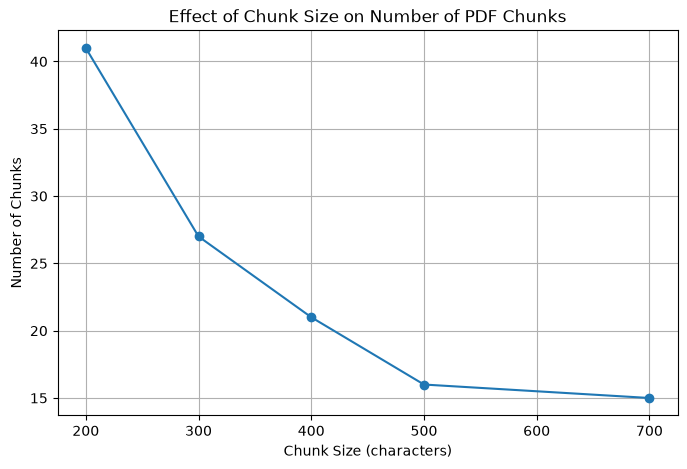

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    stats_table["chunk_size"],
    stats_table["num_chunks"],
    marker="o"
)

plt.xlabel("Chunk Size (characters)")
plt.ylabel("Number of Chunks")
plt.title("Effect of Chunk Size on Number of PDF Chunks")

plt.grid(True)
plt.show()

### Graph 2 — Average chunk length

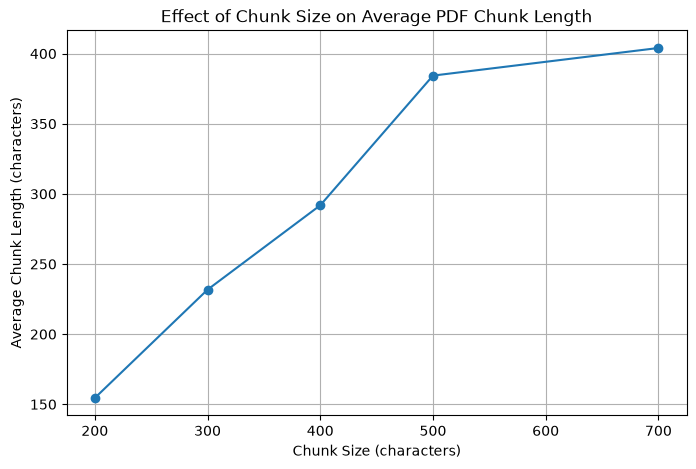

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    stats_table["chunk_size"],
    stats_table["avg_chars"],
    marker="o"
)

plt.xlabel("Chunk Size (characters)")
plt.ylabel("Average Chunk Length (characters)")
plt.title("Effect of Chunk Size on Average PDF Chunk Length")

plt.grid(True)
plt.show()

## Embeding Model

In [34]:
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 5837.23it/s]


In [35]:
print(embedding_model)

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)


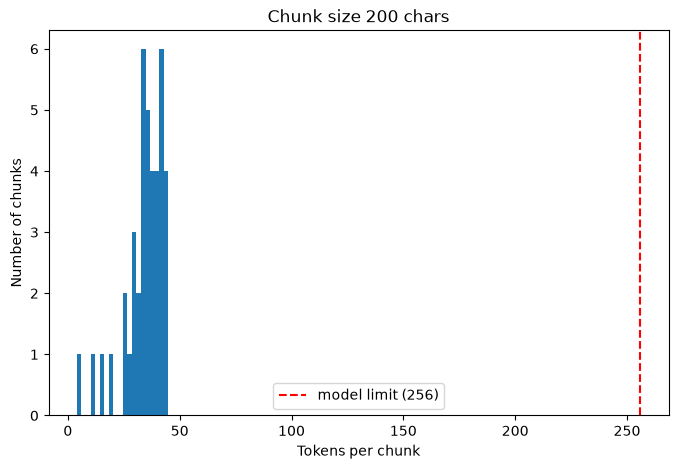

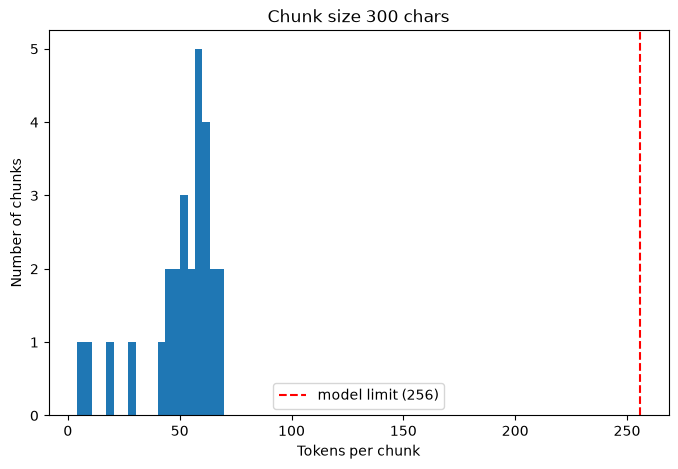

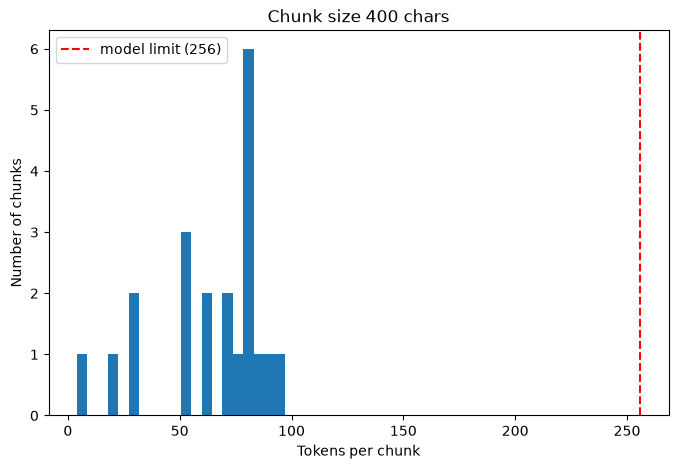

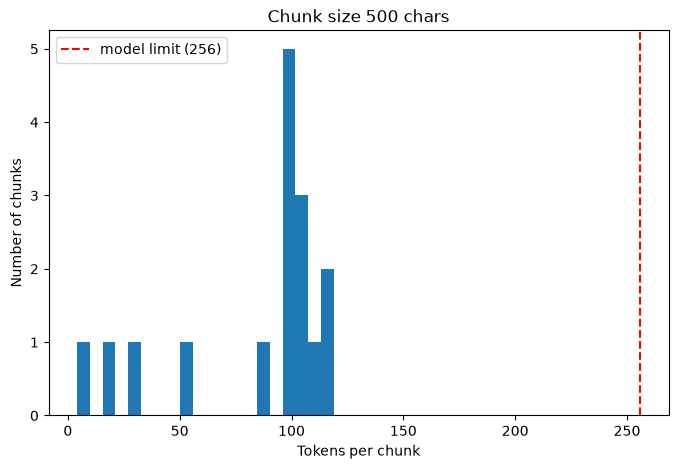

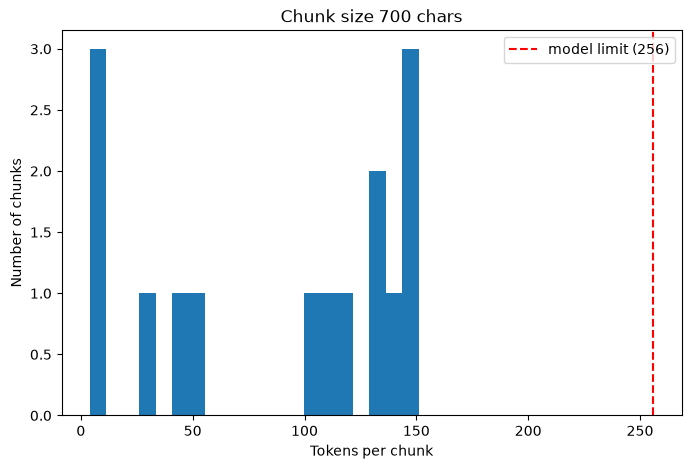

In [36]:
def plot_chunk_tokens(chunks, title=""):
    tokenizer = embedding_model.tokenizer          # reuse the loaded model's tokenizer
    max_len = embedding_model.max_seq_length       # 256 for all-MiniLM-L6-v2

    lengths = [
        len(tokenizer.encode(chunk.page_content, add_special_tokens=False))
        for chunk in chunks
    ]

    plt.figure(figsize=(8, 5))
    plt.hist(lengths, bins=20)
    plt.axvline(max_len, color="red", linestyle="--", label=f"model limit ({max_len})")
    plt.xlabel("Tokens per chunk")
    plt.ylabel("Number of chunks")
    plt.title(title)
    plt.legend()
    plt.show()

    return lengths

for size, chunks in pdf_chunks_by_size.items():
    plot_chunk_tokens(chunks, title=f"Chunk size {size} chars")

In [37]:
def retrieve_chunks(
    query,
    chunks,
    chunk_embeddings,
    top_k=5
):
    """
    Retrieve the top-k chunks for a query using
    cosine similarity between normalized embeddings.
    """

    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    )

    similarities = cosine_similarity(
        query_embedding,
        chunk_embeddings
    )[0]

    ranked_indices = np.argsort(
        similarities
    )[::-1][:top_k]

    results = []

    for rank, index in enumerate(
        ranked_indices,
        start=1
    ):
        results.append({
            "rank": rank,
            "chunk_index": int(index),
            "score": float(similarities[index]),
            "chunk": chunks[index]
        })

    return results

In [38]:
retrieval_questions = [
    {
        "id": "Q1",
        "question": "What are the common symptoms of asthma?"
    },
    {
        "id": "Q2",
        "question": "What are the common triggers of asthma?"
    },
    {
        "id": "Q3",
        "question": "What are the main types of inhalers used to treat asthma?"
    },
    {
        "id": "Q4",
        "question": "What are the criteria for well-controlled asthma?"
    },
    {
        "id": "Q5",
        "question": "What are the warning signs of an asthma attack?"
    }
]
ground_truth = {
    "Q1": {
        "answer": (
            "Common symptoms of asthma include coughing, wheezing, "
            "shortness of breath, and chest tightness."
        )
    },

    "Q2": {
        "answer": (
            "Common asthma triggers include colds and viruses, allergies, "
            "dust, pollution, smoke, stress or heightened emotions, "
            "temperature changes, hormones, and strong smells."
        )
    },

    "Q3": {
        "answer": (
            "The main inhaler types described are preventer inhalers "
            "and reliever inhalers."
        )
    },

    "Q4": {
        "answer": (
            "Well-controlled asthma includes not requiring the reliever "
            "inhaler more than three times per week, no interference with "
            "normal daily activities, no nighttime asthma symptoms, and "
            "no recent asthma attack."
        )
    },

    "Q5": {
        "answer": (
            "Warning signs of an asthma attack include a reliever inhaler "
            "not helping or being needed more frequently than every four "
            "hours, worsening wheeze, cough, chest tightness or "
            "breathlessness, and breathlessness that makes speaking, "
            "eating, or sleeping difficult."
        )
    }
}

In [39]:
pdf_embeddings_by_size = {}

for chunk_size, chunks in pdf_chunks_by_size.items():

    texts = [
        chunk.page_content
        for chunk in chunks
    ]

    embeddings = embedding_model.encode(
        texts,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    pdf_embeddings_by_size[chunk_size] = embeddings

    print(
        f"Chunk size {chunk_size}: "
        f"{embeddings.shape}"
    )

Batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  6.71it/s]


Chunk size 200: (41, 384)


Batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.51it/s]


Chunk size 300: (27, 384)


Batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.55it/s]


Chunk size 400: (21, 384)


Batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.54it/s]


Chunk size 500: (16, 384)


Batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.01it/s]

Chunk size 700: (15, 384)


In [40]:
question = retrieval_questions[0]["question"]

results = retrieve_chunks(
    query=question,
    chunks=pdf_chunks_300,
    chunk_embeddings=pdf_embeddings_by_size[300],
    top_k=5
)
for result in results:

    print(
        f"\nRank: {result['rank']}"
        f"\nChunk index: {result['chunk_index']}"
        f"\nSimilarity: {result['score']:.4f}"
    )

    print(result["chunk"].page_content)


Rank: 1
Chunk index: 9
Similarity: 0.6546
What triggers asthma symptoms?
Anything that irritates or inflames your airways can make your asthma worse.
Common triggers include:
• Colds and viruses
• Allergies – e.g. animal hair, pollen
• Dust / Pollution / Smoke
• Stress or heightened emotions
• Temperature extremes / temperature change

Rank: 2
Chunk index: 22
Similarity: 0.6429
What is an asthma attack?
Asthma and Lung UK list the following as signs of an asthma attack:
• Your reliever isn’t helping, or you are needing to take it more than every 4
hours
• Your symptoms (wheeze, cough, chest tightness, breathlessness) are getting
worse

Rank: 3
Chunk index: 1
Similarity: 0.6413
What is asthma?
Asthma is a common condition that affects the airways in and out of your lungs.
These airways can become sensitive and inflamed, making it harder to breath and
causing symptoms such as coughing, wheezing, shortness of breath, and chest
tightness.

Rank: 4
Chunk index: 5
Similarity: 0.5398
bronchi

## Retrieval Evaluation

The retrieval experiment evaluates how different recursive chunk sizes affect
semantic retrieval.

The same set of questions is used for every chunk size so that chunk size
remains the primary experimental variable.

For each question, the top 5 chunks are retrieved using cosine similarity
between the question embedding and document chunk embeddings.

In [41]:
retrieval_results = []

for chunk_size, chunks in pdf_chunks_by_size.items():

    chunk_embeddings = pdf_embeddings_by_size[chunk_size]

    for question_data in retrieval_questions:

        question_id = question_data["id"]
        question = question_data["question"]

        results = retrieve_chunks(
            query=question,
            chunks=chunks,
            chunk_embeddings=chunk_embeddings,
            top_k=5
        )

        for result in results:

            retrieval_results.append({
                "question_id": question_id,
                "question": question,
                "chunk_size": chunk_size,
                "rank": result["rank"],
                "chunk_index": result["chunk_index"],
                "similarity": result["score"]
            })

In [42]:
retrieval_results_df = pd.DataFrame(retrieval_results)

retrieval_results_df.head(15)

,question_id,question,chunk_size,rank,chunk_index,similarity
0,Q1,What are the common symptoms of asthma?,200,1,13,0.652298
1,Q1,What are the common symptoms of asthma?,200,2,27,0.646439
2,Q1,What are the common symptoms of asthma?,200,3,2,0.611728
3,Q1,What are the common symptoms of asthma?,200,4,29,0.595595
4,Q1,What are the common symptoms of asthma?,200,5,1,0.577182
5,Q2,What are the common triggers of asthma?,200,1,13,0.757303
6,Q2,What are the common triggers of asthma?,200,2,4,0.653803
7,Q2,What are the common triggers of asthma?,200,3,6,0.634223
8,Q2,What are the common triggers of asthma?,200,4,2,0.609092
9,Q2,What are the common triggers of asthma?,200,5,27,0.595179


In [43]:
top_result_df = (
    retrieval_results_df[
        retrieval_results_df["rank"] == 1
    ]
    .copy()
)

top_result_df

,question_id,question,chunk_size,rank,chunk_index,similarity
0,Q1,What are the common symptoms of asthma?,200,1,13,0.652298
5,Q2,What are the common triggers of asthma?,200,1,13,0.757303
10,Q3,What are the main types of inhalers used to tr...,200,1,17,0.674901
15,Q4,What are the criteria for well-controlled asthma?,200,1,30,0.689289
20,Q5,What are the warning signs of an asthma attack?,200,1,27,0.688733
25,Q1,What are the common symptoms of asthma?,300,1,9,0.654631
30,Q2,What are the common triggers of asthma?,300,1,9,0.752019
35,Q3,What are the main types of inhalers used to tr...,300,1,12,0.591718
40,Q4,What are the criteria for well-controlled asthma?,300,1,18,0.722480
45,Q5,What are the warning signs of an asthma attack?,300,1,22,0.712322


In [44]:
avg_similarity_by_size = (
    top_result_df
    .groupby("chunk_size")["similarity"]
    .mean()
    .reset_index(name="avg_top1_similarity")
)

avg_similarity_by_size

,chunk_size,avg_top1_similarity
0,200,0.692505
1,300,0.686634
2,400,0.664858
3,500,0.646502
4,700,0.658921


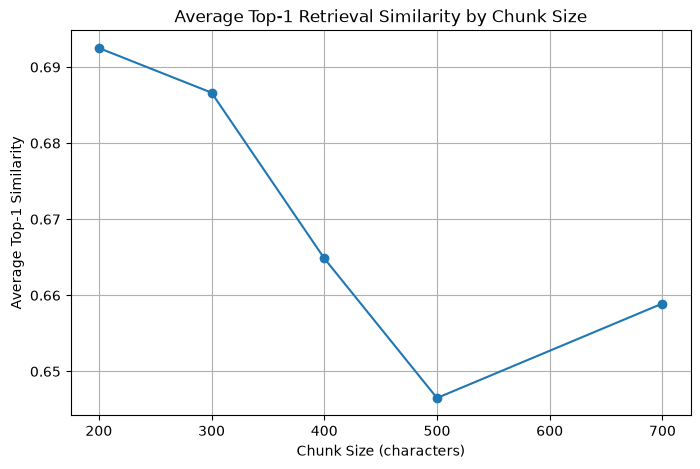

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    avg_similarity_by_size["chunk_size"],
    avg_similarity_by_size["avg_top1_similarity"],
    marker="o"
)

plt.xlabel("Chunk Size (characters)")
plt.ylabel("Average Top-1 Similarity")
plt.title("Average Top-1 Retrieval Similarity by Chunk Size")

plt.grid(True)
plt.show()

In [46]:
def show_retrieval_results(
    question_id,
    chunk_size,
    top_k=5
):

    question_data = next(
        q for q in retrieval_questions
        if q["id"] == question_id
    )

    question = question_data["question"]

    results = retrieve_chunks(
        query=question,
        chunks=pdf_chunks_by_size[chunk_size],
        chunk_embeddings=pdf_embeddings_by_size[chunk_size],
        top_k=top_k
    )

    print("=" * 80)
    print(f"{question_id}: {question}")
    print(f"Chunk size: {chunk_size}")
    print("=" * 80)

    for result in results:

        print(
            f"\nRank {result['rank']} | "
            f"Chunk {result['chunk_index']} | "
            f"Similarity: {result['score']:.4f}"
        )

        print("-" * 80)
        print(result["chunk"].page_content)

In [47]:
show_retrieval_results("Q1", 200)

Q1: What are the common symptoms of asthma?
Chunk size: 200

Rank 1 | Chunk 13 | Similarity: 0.6523
--------------------------------------------------------------------------------
What triggers asthma symptoms?
Anything that irritates or inflames your airways can make your asthma worse.
Common triggers include:
• Colds and viruses
• Allergies – e.g. animal hair, pollen

Rank 2 | Chunk 27 | Similarity: 0.6464
--------------------------------------------------------------------------------
• Your asthma does not interfere with your normal daily activities
• You do not wake at night with asthma symptoms
• You haven’t had a recent attack

Rank 3 | Chunk 2 | Similarity: 0.6117
--------------------------------------------------------------------------------
causing symptoms such as coughing, wheezing, shortness of breath, and chest
tightness.
Because the airways are so sensitive, certain things
can trigger the muscles around the airways to

Rank 4 | Chunk 29 | Similarity: 0.5956
-----------

In [48]:
show_retrieval_results("Q1", 300)

Q1: What are the common symptoms of asthma?
Chunk size: 300

Rank 1 | Chunk 9 | Similarity: 0.6546
--------------------------------------------------------------------------------
What triggers asthma symptoms?
Anything that irritates or inflames your airways can make your asthma worse.
Common triggers include:
• Colds and viruses
• Allergies – e.g. animal hair, pollen
• Dust / Pollution / Smoke
• Stress or heightened emotions
• Temperature extremes / temperature change

Rank 2 | Chunk 22 | Similarity: 0.6429
--------------------------------------------------------------------------------
What is an asthma attack?
Asthma and Lung UK list the following as signs of an asthma attack:
• Your reliever isn’t helping, or you are needing to take it more than every 4
hours
• Your symptoms (wheeze, cough, chest tightness, breathlessness) are getting
worse

Rank 3 | Chunk 1 | Similarity: 0.6413
--------------------------------------------------------------------------------
What is asthma?
Asthma

In [49]:
show_retrieval_results("Q1", 400)

Q1: What are the common symptoms of asthma?
Chunk size: 400

Rank 1 | Chunk 7 | Similarity: 0.6614
--------------------------------------------------------------------------------
What triggers asthma symptoms?
Anything that irritates or inflames your airways can make your asthma worse.
Common triggers include:
• Colds and viruses
• Allergies – e.g. animal hair, pollen
• Dust / Pollution / Smoke
• Stress or heightened emotions
• Temperature extremes / temperature change
• Hormones
• Strong smells – e.g. perfumes, aerosols, cleaning products

Rank 2 | Chunk 14 | Similarity: 0.6464
--------------------------------------------------------------------------------
• Your asthma does not interfere with your normal daily activities
• You do not wake at night with asthma symptoms
• You haven’t had a recent attack

Rank 3 | Chunk 1 | Similarity: 0.6234
--------------------------------------------------------------------------------
What is asthma?
Asthma is a common condition that affects the a

In [50]:
show_retrieval_results("Q1", 500)

Q1: What are the common symptoms of asthma?
Chunk size: 500

Rank 1 | Chunk 6 | Similarity: 0.6383
--------------------------------------------------------------------------------
What triggers asthma symptoms?
Anything that irritates or inflames your airways can make your asthma worse.
Common triggers include:
• Colds and viruses
• Allergies – e.g. animal hair, pollen
• Dust / Pollution / Smoke
• Stress or heightened emotions
• Temperature extremes / temperature change
• Hormones
• Strong smells – e.g. perfumes, aerosols, cleaning products
Some people can have exercise induced asthma but using a reliever medication
before exercise can often prevent symptoms.

Rank 2 | Chunk 1 | Similarity: 0.6124
--------------------------------------------------------------------------------
What is asthma?
Asthma is a common condition that affects the airways in and out of your lungs.
These airways can become sensitive and inflamed, making it harder to breath and
causing symptoms such as coughing, w

In [51]:
show_retrieval_results("Q1", 700)

Q1: What are the common symptoms of asthma?
Chunk size: 700

Rank 1 | Chunk 6 | Similarity: 0.6383
--------------------------------------------------------------------------------
What triggers asthma symptoms?
Anything that irritates or inflames your airways can make your asthma worse.
Common triggers include:
• Colds and viruses
• Allergies – e.g. animal hair, pollen
• Dust / Pollution / Smoke
• Stress or heightened emotions
• Temperature extremes / temperature change
• Hormones
• Strong smells – e.g. perfumes, aerosols, cleaning products
Some people can have exercise induced asthma but using a reliever medication
before exercise can often prevent symptoms.

Rank 2 | Chunk 12 | Similarity: 0.6144
--------------------------------------------------------------------------------
your asthma nurse to provide you with a plan if you do not have one.
What is an asthma attack?
Asthma and Lung UK list the following as signs of an asthma attack:
• Your reliever isn’t helping, or you are needin

In [52]:
evidence_map = {
    "Q1": ["symptoms such as coughing, wheezing",
           "shortness of breath, and chest tightness"],
    "Q2": ["Colds and viruses", "Dust / Pollution / Smoke",
           "Stress or heightened emotions", "Temperature extremes",
           "Strong smells"],
    "Q3": ["Preventer inhalers try to stop", "Reliever inhalers help to relieve"],
    "Q4": ["more than 3 times per week",
           "does not interfere with your normal daily activities",
           "wake at night with asthma symptoms",
           "had a recent attack"],
    "Q5": ["needing to take it more than every 4 hours",
           "are getting worse",
           "difficult to speak, eat or sleep",
           "catch your breath properly"],
}
for qid, ev in evidence_map.items():
    ground_truth[qid]["evidence"] = ev

new_questions = [
    {"id": "Q6",  "type": "paraphrase", "question": "What can make my breathing worse?",
     "evidence": ["Colds and viruses", "Dust / Pollution / Smoke", "Strong smells"]},
    {"id": "Q7",  "type": "fact", "question": "How is asthma diagnosed?",
     "evidence": ["There is no one test to diagnose asthma",
                  "symptom history and the results of breathing tests"]},
    {"id": "Q8",  "type": "fact", "question": "What should I do during an asthma attack?",
     "evidence": ["Sit up straight", "Take one puff of your reliever inhaler", "call 999"]},
    {"id": "Q9",  "type": "multi", "question": "What makes someone more likely to develop asthma?",
     "evidence": ["It can run in families", "Premature birth or low birth weight",
                  "Occupational exposure", "Hormones can play a part"]},
    {"id": "Q10", "type": "paraphrase", "question": "Do I still need my preventer inhaler when I feel well?",
     "evidence": ["taken every day even if you are symptom free"]},
    {"id": "Q11", "type": "paraphrase", "question": "Can exercise trigger asthma and how can it be prevented?",
     "evidence": ["exercise induced asthma", "reliever medication before exercise"]},
    {"id": "Q12", "type": "multi", "question": "How serious is asthma?",
     "evidence": ["around 5% of all people with asthma",
                  "even if you consider your asthma to be mild"]},
]

for q in new_questions:
    retrieval_questions.append({"id": q["id"], "question": q["question"]})
    ground_truth[q["id"]] = {"type": q["type"], "evidence": q["evidence"]}

In [53]:
def norm(s):
    return re.sub(r"\s+", " ", s).lower()

all_text = " ".join(norm(d.page_content) for d in pdf_documents)
for qid, gt in ground_truth.items():
    for e in gt["evidence"]:
        assert norm(e) in all_text, f"{qid}: not found -> {e}"
print("All evidence phrases found.")

All evidence phrases found.


In [54]:
def score_query(evidence, retrieved, k):
    texts = [norm(c.page_content) for c in retrieved[:k]]
    ev = [norm(e) for e in evidence]
    precision = sum(any(e in t for e in ev) for t in texts) / k
    recall = sum(any(e in t for t in texts) for e in ev) / len(ev)
    return precision, recall, float(recall > 0)

eval_rows = []
for chunk_size, chunks in pdf_chunks_by_size.items():
    for q in retrieval_questions:
        evidence = ground_truth[q["id"]]["evidence"]
        if not evidence:            # unanswerable: nothing to score
            continue
        results = retrieve_chunks(q["question"], chunks,
                                  pdf_embeddings_by_size[chunk_size], top_k=5)
        retrieved = [r["chunk"] for r in results]
        for k in (1, 3, 5):
            p, rec, hit = score_query(evidence, retrieved, k)
            eval_rows.append({"chunk_size": chunk_size, "k": k, "id": q["id"],
                              "precision": p, "recall": rec, "hit": hit})

eval_df = pd.DataFrame(eval_rows)
eval_df.groupby(["chunk_size", "k"])[["precision", "recall", "hit"]].mean().round(3)

precision  recall    hit
chunk_size k                          
200        1      0.250   0.142  0.250
           3      0.222   0.371  0.583
           5      0.167   0.433  0.583
300        1      0.500   0.358  0.500
           3      0.306   0.622  0.750
           5      0.183   0.622  0.750
400        1      0.333   0.250  0.333
           3      0.389   0.812  0.833
           5      0.250   0.896  0.917
500        1      0.583   0.521  0.583
           3      0.333   0.812  0.917
           5      0.233   0.958  1.000
700        1      0.750   0.681  0.750
           3      0.306   0.847  0.917
           5      0.200   0.889  0.917

700 is best when K is small, and 500 is best when K is large.
